In [2]:
# Install the required libraries
%pip install matplotlib pandas seaborn numpy

# Import the required libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

  Using cached pytz-2025.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.1-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 10.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 10.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ------- -------------------------------- 2.1/11.5 MB 11.5 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.5 MB 11.4 MB/s eta 0:00:01
   ------------------------ --------------- 7.1/11.5 MB 11.4 MB/s eta 0:00:01
   ------------------------------- -------- 9.2/11.5 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.5 MB 11.2 MB/s eta 0:00:01
   --------------------------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
competitor_analysis = pd.read_csv('competitor_analysis.csv')
price_increase_analysis = pd.read_csv('price_increse_analysis.csv')
transcript = pd.read_csv('transcript.csv')


In [ ]:
competitor_analysis.head()

,Unnamed: 0,Contact_ID,Source_Folder,Explicit_Competitor_Mention,Implied_Competitor_Mention,Explicit_Switching_Intent,Implied_Switching_Intent,Competitor_Names_Listed,Mentioned_Alcumus_Competitors
0,0,537988364615,02_09_2024,No,No,No,No,COMP_NO,No
1,1,537988367170,02_09_2024,No,No,No,No,COMP_NO,No
2,2,537988370256,02_09_2024,No,No,No,No,COMP_NO,No
3,3,537988474219,02_09_2024,No,No,No,No,COMP_NO,No
4,4,538174552516,02_09_2024,No,No,No,No,COMP_NO,No


In [12]:
transcript.head()

,Unnamed: 0,Contact_ID,Start_Date,Prospect Outcome,Prospect Status,Prospect Renewal Date,Renewal Month,Payment Method,Renewal Score at release,Proforma Membership Status,...,Band,Date Paid,Payment Timeframe,Payment Time Frame 2,Payment Time Frame 3,Total Net Paid,Starting Net,Auto Renewal - Proforma Release,Now on Auto Renewal,Process
0,0,538175801914,2024-09-03,Won,Renewed,2024-10-23,2024-10-01,BACS,27.0,Accredited,...,Band D,2024-10-28 00:00:00.000,5.0,Within 13 Days After Renewal,Paid Late,1279.0,1279,0,0,process
1,1,538176256176,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,25.5,Accredited,...,Band C2,2024-10-01 04:00:35.710,0.0,On Renewal Date,Paid on Time,1099.0,1099,1,1,process
2,2,538176270449,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,23.5,Accredited,...,Band C1,2024-10-01 04:00:27.953,0.0,On Renewal Date,Paid on Time,799.0,799,1,1,process
3,3,538176276504,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,26.0,Accredited,...,Band C1,2024-10-01 04:00:27.057,0.0,On Renewal Date,Paid on Time,799.0,799,1,1,process
4,4,538176294696,2024-09-04,Lost,No Longer Trading,2024-10-01,2024-10-01,NaN,25.0,In Progress,...,Band C2,NaN,NaN,NaN,NaN,NaN,949,1,0,process


In [13]:
price_increase_analysis.head()

,Contact_ID,Source_Folder,Q1_Topic_Introduced_By,Q2_Price_Increase_Introduction,Q3_Renewal_Fee_Mentioned,Q4_Percentage_Price_Increase_Mentioned,Q5_Monetary_Price_Increase_Mentioned,Q6_Price_Range_Mentioned,Q7_Customer_Asked_For_Justification,Q10_Customer_Response,Q11_Desire_To_Cancel,Q12_Discount_Offered,Q14_Agent_Response_To_Cancel,Previous_Year_Price,Current_Year_Price
0,537988364615,02_09_2024,Not Discussed,Not Discussed,No,No,No,Not Discussed,No,Neutral,Not Discussed,No,Not Discussed,Not Applicable,Not Applicable
1,537988367170,02_09_2024,Agent,The agent mentioned the upcoming renewal and t...,No,No,No,Not Discussed,No,Positive,Renewed,No,Not Discussed,Not Applicable,Not Applicable
2,537988370256,02_09_2024,Not Discussed,Not Discussed,No,No,No,Not Discussed,No,Neutral,Not Discussed,No,Not Discussed,Not Applicable,Not Applicable
3,537988474219,02_09_2024,Not Discussed,Not Discussed,No,No,No,Not Discussed,No,Neutral,Not Discussed,No,Not Discussed,Not Applicable,Not Applicable
4,538174552516,02_09_2024,Agent,The price increase was introduced as part of t...,"Yes, £845",No,Yes,£695 to £845,Yes,Neutral,Renewed,No,Not Discussed,£695,£845


In [21]:
price_increase_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Contact_ID                              12429 non-null  int64         
 1   Source_Folder                           12429 non-null  datetime64[ns]
 2   Q1_Topic_Introduced_By                  3779 non-null   object        
 3   Q2_Price_Increase_Introduction          3820 non-null   object        
 4   Q3_Renewal_Fee_Mentioned                12202 non-null  object        
 5   Q4_Percentage_Price_Increase_Mentioned  12373 non-null  object        
 6   Q5_Monetary_Price_Increase_Mentioned    12373 non-null  object        
 7   Q6_Price_Range_Mentioned                698 non-null    object        
 8   Q7_Customer_Asked_For_Justification     12373 non-null  object        
 9   Q10_Customer_Response                   10327 non-

In [11]:
price_increase_analysis.drop(columns=["Unnamed: 0"], inplace=True)

In [20]:
price_increase_analysis["Source_Folder"] = pd.to_datetime(price_increase_analysis["Source_Folder"], format="%d_%m_%Y")

In [25]:
price_increase_analysis["Source_Folder"].head()

0   2024-09-02
1   2024-09-02
2   2024-09-02
3   2024-09-02
4   2024-09-02
Name: Source_Folder, dtype: datetime64[ns]

In [26]:
miss=price_increase_analysis.isnull().sum()
miss

Contact_ID                                    0
Source_Folder                                 0
Q1_Topic_Introduced_By                     8650
Q2_Price_Increase_Introduction             8609
Q3_Renewal_Fee_Mentioned                    227
Q4_Percentage_Price_Increase_Mentioned       56
Q5_Monetary_Price_Increase_Mentioned         56
Q6_Price_Range_Mentioned                  11731
Q7_Customer_Asked_For_Justification          56
Q10_Customer_Response                      2102
Q11_Desire_To_Cancel                       6480
Q12_Discount_Offered                         56
Q14_Agent_Response_To_Cancel              11292
Previous_Year_Price                       11731
Current_Year_Price                        11731
dtype: int64

In [ ]:
# Drop the 'Unnamed: 0' column as it is not needed
transcript.drop(columns=["Unnamed: 0"], inplace=True)

# Convert 'Start_Date' and 'Prospect Renewal Date' to datetime format
transcript['Start_Date'] = pd.to_datetime(transcript['Start_Date'], format="%Y-%m-%d")
transcript['Prospect Renewal Date'] = pd.to_datetime(transcript['Prospect Renewal Date'], format="%Y-%m-%d")

# Fill missing values in 'Payment Method' with 'Unknown'
transcript['Payment Method'].fillna('Unknown', inplace=True)

# Fill missing values in 'Tenure Group' with 'Unknown'
transcript['Tenure Group'].fillna('Unknown', inplace=True)

# Fill missing values in 'Date Paid' with 'NaT' (Not a Time)
transcript['Date Paid'] = pd.to_datetime(transcript['Date Paid'], errors='coerce')

# Fill missing values in numerical columns with 0
transcript['Payment Timeframe'].fillna(0, inplace=True)
transcript['Total Net Paid'].fillna(0, inplace=True)

# Display the cleaned DataFrame


KeyError: "['Unnamed: 0'] not found in axis"

In [33]:
transcript.head()

,Contact_ID,Start_Date,Prospect Outcome,Prospect Status,Prospect Renewal Date,Renewal Month,Payment Method,Renewal Score at release,Proforma Membership Status,Anchor or Indie,...,Band,Date Paid,Payment Timeframe,Payment Time Frame 2,Payment Time Frame 3,Total Net Paid,Starting Net,Auto Renewal - Proforma Release,Now on Auto Renewal,Process
0,538175801914,2024-09-03,Won,Renewed,2024-10-23,2024-10-01,BACS,27.0,Accredited,Anchored,...,Band D,2024-10-28 00:00:00.000,5.0,Within 13 Days After Renewal,Paid Late,1279.0,1279,0,0,process
1,538176256176,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,25.5,Accredited,Independent,...,Band C2,2024-10-01 04:00:35.710,0.0,On Renewal Date,Paid on Time,1099.0,1099,1,1,process
2,538176270449,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,23.5,Accredited,Independent,...,Band C1,2024-10-01 04:00:27.953,0.0,On Renewal Date,Paid on Time,799.0,799,1,1,process
3,538176276504,2024-09-04,Won,Renewed,2024-10-01,2024-10-01,CARD,26.0,Accredited,Independent,...,Band C1,2024-10-01 04:00:27.057,0.0,On Renewal Date,Paid on Time,799.0,799,1,1,process
4,538176294696,2024-09-04,Lost,No Longer Trading,2024-10-01,2024-10-01,Unknown,25.0,In Progress,Anchored,...,Band C2,NaT,0.0,NaN,NaN,0.0,949,1,0,process


In [ ]:
Here are three hypotheses for customer expansion:

1. **Hypothesis 1:**
    Customers who have a higher tenure with the company are more likely to expand their services.
    - **Rationale:** Long-term customers may have developed trust and satisfaction with the company's services, making them more likely to consider additional offerings.

2. **Hypothesis 2:**
    Customers who have had positive interactions with customer support are more likely to expand their services.
    - **Rationale:** Positive experiences with customer support can enhance customer satisfaction and loyalty, leading to a higher likelihood of service expansion.

3. **Hypothesis 3:**
    Customers who have received discounts or special offers are more likely to expand their services.
    - **Rationale:** Discounts and special offers can incentivize customers to try new services, leading to potential expansion of their service portfolio.

In [ ]:
```markdown
### Visualizations to Prove Hypotheses

#### Hypothesis 1: Customers who have a higher tenure with the company are more likely to expand their services.
- **Visualization:** A bar plot showing the relationship between customer tenure and service expansion.

```python
# Plotting the relationship between tenure and service expansion
plt.figure(figsize=(10, 6))
sns.countplot(data=transcript, x='Tenure Group', hue='Prospect Outcome')
plt.title('Customer Tenure vs. Service Expansion')
plt.xlabel('Tenure Group')
plt.ylabel('Count')
plt.legend(title='Prospect Outcome')
plt.show()
```

#### Hypothesis 2: Customers who have had positive interactions with customer support are more likely to expand their services.
- **Visualization:** A bar plot showing the relationship between customer support interactions and service expansion.

```python
# Plotting the relationship between customer support interactions and service expansion
plt.figure(figsize=(10, 6))
sns.countplot(data=transcript, x='Prospect Status', hue='Prospect Outcome')
plt.title('Customer Support Interactions vs. Service Expansion')
plt.xlabel('Prospect Status')
plt.ylabel('Count')
plt.legend(title='Prospect Outcome')
plt.show()
```

#### Hypothesis 3: Customers who have received discounts or special offers are more likely to expand their services.
- **Visualization:** A bar plot showing the relationship between discounts/special offers and service expansion.

```python
# Plotting the relationship between discounts/special offers and service expansion
plt.figure(figsize=(10, 6))
sns.countplot(data=price_increase_analysis, x='Q12_Discount_Offered', hue='Q10_Customer_Response')
plt.title('Discounts/Special Offers vs. Service Expansion')
plt.xlabel('Discounts/Special Offers')
plt.ylabel('Count')
plt.legend(title='Customer Response')
plt.show()
```
```

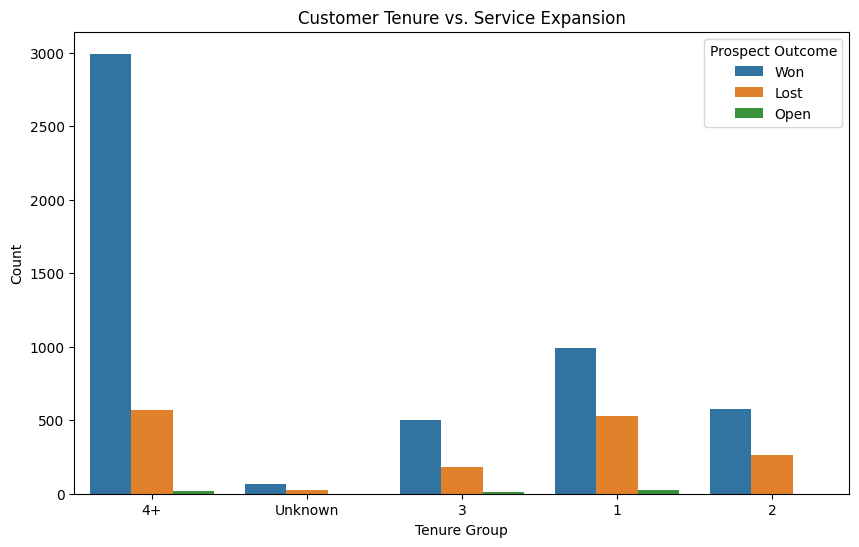

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=transcript, x='Tenure Group', hue='Prospect Outcome')
plt.title('Customer Tenure vs. Service Expansion')
plt.xlabel('Tenure Group')
plt.ylabel('Count')
plt.legend(title='Prospect Outcome')
plt.show()

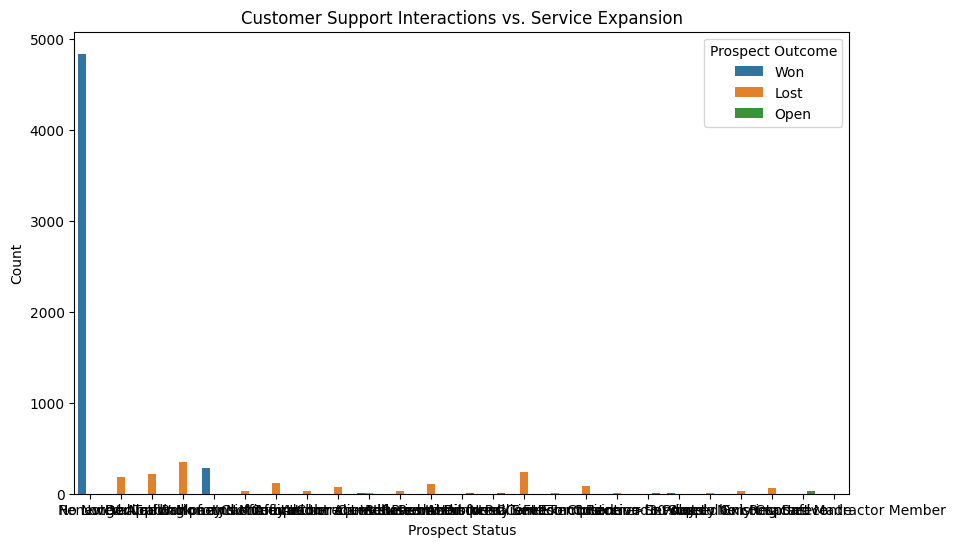

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(data=transcript, x='Prospect Status', hue='Prospect Outcome')
plt.title('Customer Support Interactions vs. Service Expansion')
plt.xlabel('Prospect Status')
plt.ylabel('Count')
plt.legend(title='Prospect Outcome')
plt.show()

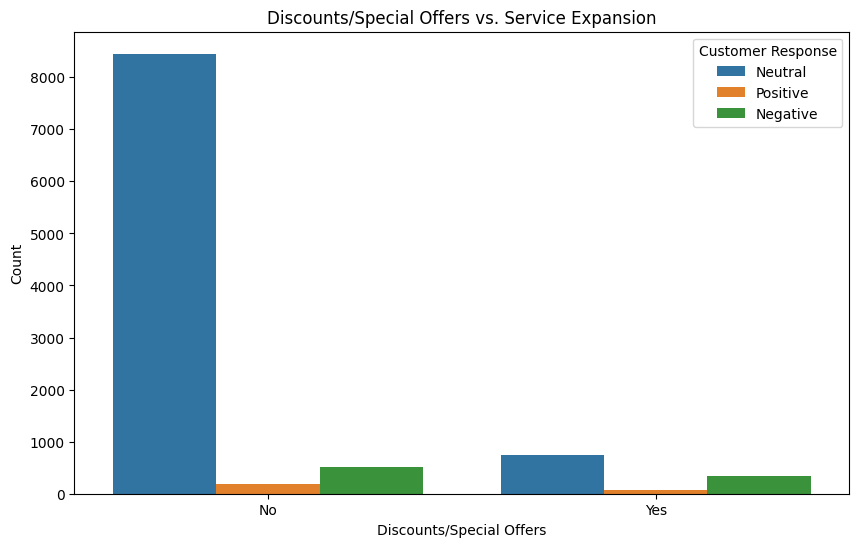

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=price_increase_analysis, x='Q12_Discount_Offered', hue='Q10_Customer_Response')
plt.title('Discounts/Special Offers vs. Service Expansion')
plt.xlabel('Discounts/Special Offers')
plt.ylabel('Count')
plt.legend(title='Customer Response')
plt.show()